<a href="https://colab.research.google.com/github/saraal1/IT326_Project/blob/main/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data Analysis

In [1]:
import pandas as pd

# Load directly from GitHub repository raw link
url = "https://raw.githubusercontent.com/saraal1/IT326_Project/main/Dataset/Raw_dataset.csv"
df = pd.read_csv(url)

## 1.1 Statistical summary

In [2]:
# Display the statistical summary of numerical attributes
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


The statistical summary shows important information about the numerical features, including the mean, standard deviation, and range of values. It helps identify the distribution and variability of the data.

## 1.2 Missing Values Analysis

Missing Values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Total missing values: 0


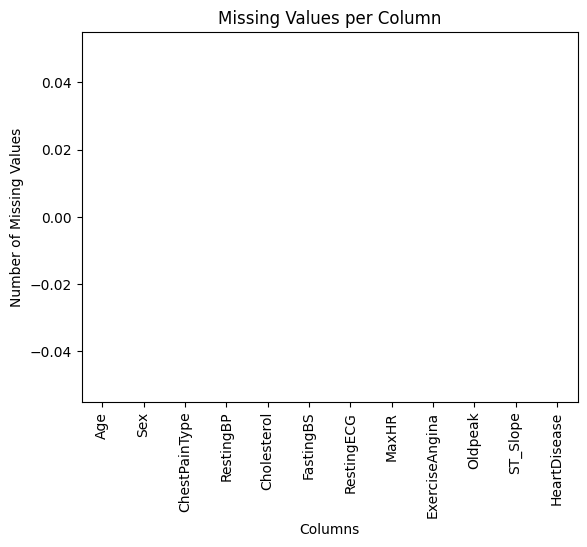

In [3]:
import matplotlib.pyplot as plt

# Count missing values in each column
missing_values = df.isna().sum()

print("Missing Values:")
print(missing_values)

# Display the total number of missing values
print("\nTotal missing values:", missing_values.sum())

# Plot missing values per column
plt.figure()
missing_values.plot(kind="bar")
plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.show()

The analysis reveals that there are 0 missing values across all attributes in the dataset. Therefore, no imputation (mean/median replacement) or tuple removal (dropna()) was required.

## 1.3 Five Number Summary

In [4]:
# Select numerical attributes, excluding the target class
numeric_df = df.select_dtypes(include='number').drop(
    columns=['HeartDisease'], errors='ignore'
)

# Calculate the five-number summary
five_number_summary = numeric_df.describe().loc[
    ['min', '25%', '50%', '75%', 'max']
]

# Display the five-number summary
five_number_summary

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
min,28.0,0.0,0.00,0.0,60.0,-2.6
25%,47.0,120.0,173.25,0.0,120.0,0.0
50%,54.0,130.0,223.00,0.0,138.0,0.6
75%,60.0,140.0,267.00,0.0,156.0,1.5
max,77.0,200.0,603.00,1.0,202.0,6.2


The five number summary shows the minimum,first quartile (Q1), median (Q2), third quartile (Q3), and maximum values of each numerical attribute. It helps us understand the data distribution, measure its spread, and identify potential outliers.

## 1.4 Outliers Analysis

In [5]:
# Calculate the first and third quartiles
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)

# Calculate the interquartile range (IQR)
IQR = Q3 - Q1

# Identify potential outliers using the IQR method
outliers = ((numeric_df < (Q1 - 1.5 * IQR)) |
            (numeric_df > (Q3 + 1.5 * IQR)))

# Count the potential outliers in each numerical attribute
outliers.sum()

,0
Age,0
RestingBP,28
Cholesterol,183
FastingBS,214
MaxHR,2
Oldpeak,16


The IQR method was used to identify potential outliers. Cholesterol and FastingBS showed the highest number of potential outliers, while Age had none. These values will be further examined using boxplots.

## 1.5 BoxPlots

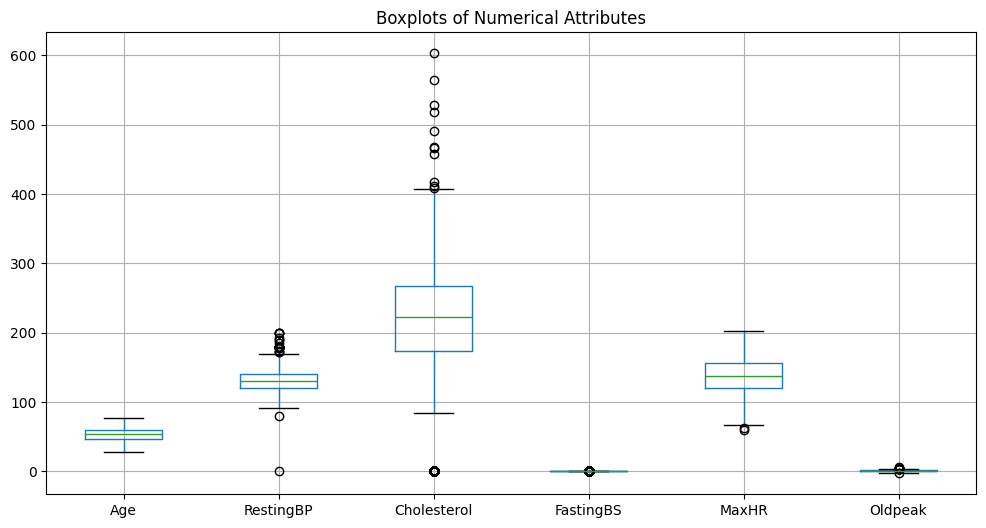

In [6]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Create boxplots for numerical attributes
numeric_df.boxplot(figsize=(12, 6))

# Add a title to the plot
plt.title('Boxplots of Numerical Attributes')

# Display the plot
plt.show()

The boxplots summarize the distribution of the numerical attributes by showing their median, quartiles, spread, and potential outliers. The plots indicate potential outliers in RestingBP, Cholesterol, MaxHR, and Oldpeak, while Cholesterol shows several extreme values, including values close to zero. These findings, observed before preprocessing, indicate that some numerical attributes contain extreme observations that may affect the analysis. Therefore, the dataset requires further preprocessing to examine and handle these extreme values.

## 1.6 Data Visualization

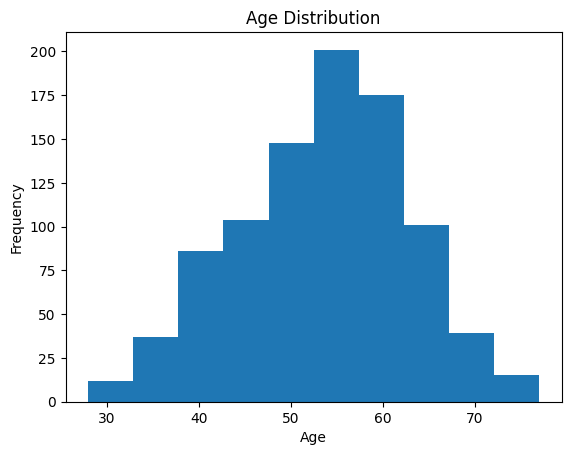

In [7]:
import matplotlib.pyplot as plt

plt.hist(df["Age"])
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()


This histogram shows the distribution of patients' ages. Most patients are between 50 and 60 years old.


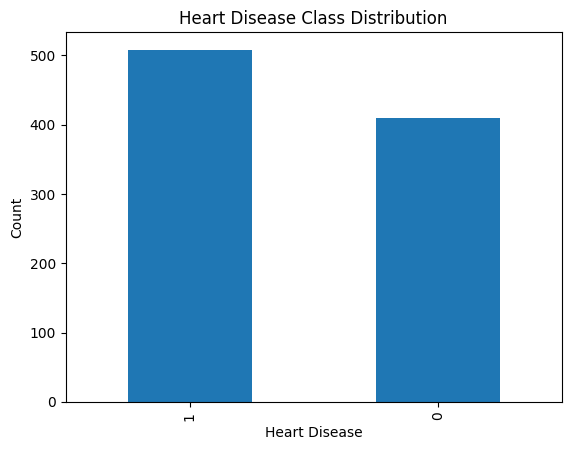

In [8]:
df["HeartDisease"].value_counts().plot(kind="bar")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.title("Heart Disease Class Distribution")
plt.show()


This bar plot shows the distribution of HeartDisease classes. Class 1 has 508 records, while Class 0 has 410 records.


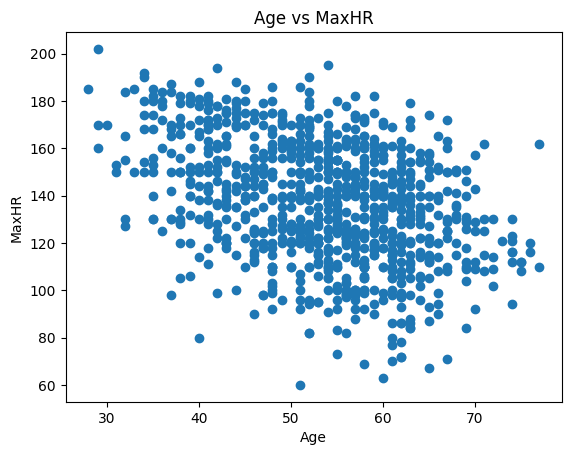

In [9]:
plt.scatter(df["Age"], df["MaxHR"])
plt.xlabel("Age")
plt.ylabel("MaxHR")
plt.title("Age vs MaxHR")
plt.show()


This scatter plot shows the relationship between Age and Maximum Heart Rate (MaxHR). It shows that MaxHR generally decreases as age increases.


# Data Processing


## 2.1 Noise Removal

In [10]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

#Snapshot of the raw dataset
print("Raw Dataset:")
print(df.head())

# Keep a copy of the raw dataset unchanged
Preprocessed_dataset = df.copy()

# Specify the numeric attributes for outlier analysis
num_cols = ["Age", "RestingBP","Cholesterol", "MaxHR", "Oldpeak"]

# Calculate absolute Z-scores for the numeric attributes
z_scores = np.abs(zscore(Preprocessed_dataset[num_cols]))

# Set threshold to 3.0 to target extreme outliers only
threshold = 3.0

# Identify rows containing at least one extreme outlier across the selected attributes
noisy_rows_mask = (z_scores > threshold).any(axis=1)

# Separate the noisy/removed rows
removed_rows = Preprocessed_dataset[noisy_rows_mask]

# Produce the cleaned dataset
Preprocessed_dataset = Preprocessed_dataset[~noisy_rows_mask]

# Display summary of noise removal results
print(f"\n\nNumber of removed noisy rows: {len(removed_rows)}")
print(" Removed rows (Outliers):")
print(removed_rows.head())
print(f"\n\nRemaining rows in Preprocessed_dataset: {len(Preprocessed_dataset)}")
#Snapshot of the Preprocessed dataset
print("Preprocessed_dataset:")
print(Preprocessed_dataset.head())

Raw Dataset:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


Number of removed noisy rows: 19
 Removed rows (Outliers):
     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
76    32   M           ASY        118          529       

Noise removal was performed to improve the quality and reliability of the dataset by detecting outliers. The **Z-score method** was used because it effectively measures how many standard deviations an observation is from the mean, making it ideal for continuous numerical attributes and ensuring that only extreme noise is removed.
The Z-score method was applied to the continuous numerical attributes:
* Age
* RestingBP
* Cholesterol
* MaxHR
* Oldpeak

For each continuous numerical attribute, the absolute Z-score was calculated. A **threshold of 3.0** was applied, and observations falling outside this boundary were identified as extreme outliers and removed from the preprocessed dataset.
The removed rows were stored separately in `removed_rows`, while the original dataset (`df`) remained unchanged. This preprocessing step reduces the influence of extreme observations and improves the consistency of the dataset, making subsequent analysis, visualization more reliable and stable.

## 2.2 Feature Selection

In [11]:
import pandas as pd
from scipy.stats import chi2_contingency

#Snapshot of the raw dataset
print("Raw Dataset:")
print(df.head())

#Creating contingency table between target variable(HeartDisease) and categorical attribute(ChestPainType)
contingency_table = pd.crosstab(Preprocessed_dataset['ChestPainType'], Preprocessed_dataset['HeartDisease'])
print("\nContingency Table:")
print(contingency_table)

#Perform the chi-square test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

#print the results
print("\nChi-Square Statistic:", chi2_stat)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:")
print(expected)
#Snapshot of the Preprocessed dataset
print("\nPreprocessed_dataset:")
print(Preprocessed_dataset.head())


Raw Dataset:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

Contingency Table:
HeartDisease     0    1
ChestPainType          
ASY            104  379
ATA            148   23
NAP            130   70
TA              25   20

Chi-Square Statistic: 260.798

Feature selection was applied to identify attributes that have a meaningful relationship with the target variable(HeartDisease). The Chi-Square test of independence was used because both ChestPainType and HeartDisease are categorical variables.A contingency table was first created to show the distribution of HeartDisease cases across the different ChestPainType categories. The Chi-Square test was then performed, and the Chi-Square statistic, degrees of freedom, and expected frequencies were calculated.This technique helps identify the relationship between categorical attributes and the target variable. Selecting relevant features can reduce irrelevant information and make the dataset more suitable for subsequent analysis.

In [12]:
from sklearn.preprocessing import LabelEncoder

print("--- Before Variable Transformation ---")
display(Preprocessed_dataset.head())

categorical_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]

label_encoders = {}
for col in categorical_cols:
  le = LabelEncoder()
  Preprocessed_dataset[col] = le.fit_transform(Preprocessed_dataset[col])
  label_encoders[col] = le

print("\n--- After Variable Transformation (Encoded) ---")
display(Preprocessed_dataset.head())

--- Before Variable Transformation ---


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0



--- After Variable Transformation (Encoded) ---


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


In [13]:
from sklearn.preprocessing import MinMaxScaler

print("--- Before Normalization ---")
display(Preprocessed_dataset.head())

continuous_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]

scaler = MinMaxScaler()
Preprocessed_dataset[continuous_cols] = scaler.fit_transform(
    Preprocessed_dataset[continuous_cols]
)

print("\n--- After Normalization (Scaled [0, 1]) ---")
display(Preprocessed_dataset.head())

print("\n" + "=" * 50)
print("=== Final Raw vs Preprocessed Comparison ===")
print("Raw Dataset Snapshot:")
display(df.head())

print("Final Preprocessed Dataset Snapshot:")
display(Preprocessed_dataset.head())

Preprocessed_dataset.to_csv("Preprocessed_dataset.csv", index=False)
print("\nFinal dataset saved successfully as 'Preprocessed_dataset.csv'")

--- Before Normalization ---


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0



--- After Normalization (Scaled [0, 1]) ---


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,0.244898,1,1,0.571429,0.557915,0,1,0.784173,0,0.333333,2,0
1,0.428571,0,2,0.761905,0.347490,0,1,0.669065,0,0.500000,1,1
2,0.183673,1,1,0.476190,0.546332,0,2,0.251799,0,0.333333,2,0
3,0.408163,0,0,0.552381,0.413127,0,1,0.323741,1,0.583333,1,1
4,0.530612,1,2,0.666667,0.376448,0,1,0.424460,0,0.333333,2,0



=== Final Raw vs Preprocessed Comparison ===
Raw Dataset Snapshot:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Final Preprocessed Dataset Snapshot:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,0.244898,1,1,0.571429,0.557915,0,1,0.784173,0,0.333333,2,0
1,0.428571,0,2,0.761905,0.347490,0,1,0.669065,0,0.500000,1,1
2,0.183673,1,1,0.476190,0.546332,0,2,0.251799,0,0.333333,2,0
3,0.408163,0,0,0.552381,0.413127,0,1,0.323741,1,0.583333,1,1
4,0.530612,1,2,0.666667,0.376448,0,1,0.424460,0,0.333333,2,0



Final dataset saved successfully as 'Preprocessed_dataset.csv'


### 2.3 Variable Transformation Justification
- **Why applied:** Machine learning algorithms require numerical inputs to process data mathematically. Categorical features like `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, and `ST_Slope` contain textual categories.
- **Attributes applied to:** `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, and `ST_Slope`.
- **How it improved the dataset:** Converted qualitative strings into structured numerical labels using `LabelEncoder`, making them directly compatible with distance calculations and classification models without losing information.

### 2.4 Normalization Justification
- **Why applied:** Numeric features had drastically different ranges (e.g., `Cholesterol` reaching above 500 while `Oldpeak` has small decimal values). Without scaling, attributes with larger magnitudes dominate distance-based and gradient-based algorithms.
- **Attributes applied to:** Continuous numerical features (`Age`, `RestingBP`, `Cholesterol`, `MaxHR`, `Oldpeak`).
- **How it improved the dataset:** `MinMaxScaler` transformed all continuous features onto a uniform scale $[0, 1]$, preventing feature bias, stabilizing model performance, and ensuring equal weighting during learning.